<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 846 | Val: 205 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 128)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.65e-05 | train loss 1.3210 acc 0.398 | val loss 1.1683 acc 0.644 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.65e-05 | train loss 1.1242 acc 0.645 | val loss 0.9535 acc 0.741 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.65e-05 | train loss 0.8466 acc 0.720 | val loss 0.7203 acc 0.771 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.65e-05 | train loss 0.6306 acc 0.755 | val loss 0.5376 acc 0.834 *


...

[ConvNeXt-Tiny] Epoch  15/100 | LR: 5.65e-05 | train loss 0.1449 acc 0.918 | val loss 0.3376 acc 0.898


[ConvNeXt-Tiny] Epoch  16/100 | LR: 5.65e-05 | train loss 0.0699 acc 0.979 | val loss 0.3597 acc 0.898


[ConvNeXt-Tiny] Epoch  17/100 | LR: 5.65e-05 | train loss 0.0710 acc 0.967 | val loss 0.3469 acc 0.873


[ConvNeXt-Tiny] Epoch  18/100 | LR: 5.65e-05 | train loss 0.0687 acc 0.974 | val loss 0.3706 acc 0.883


[ConvNeXt-Tiny] Epoch  19/100 | LR: 5.65e-05 | train loss 0.0568 acc 0.975 | val loss 0.3905 acc 0.883

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 19.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.2973)


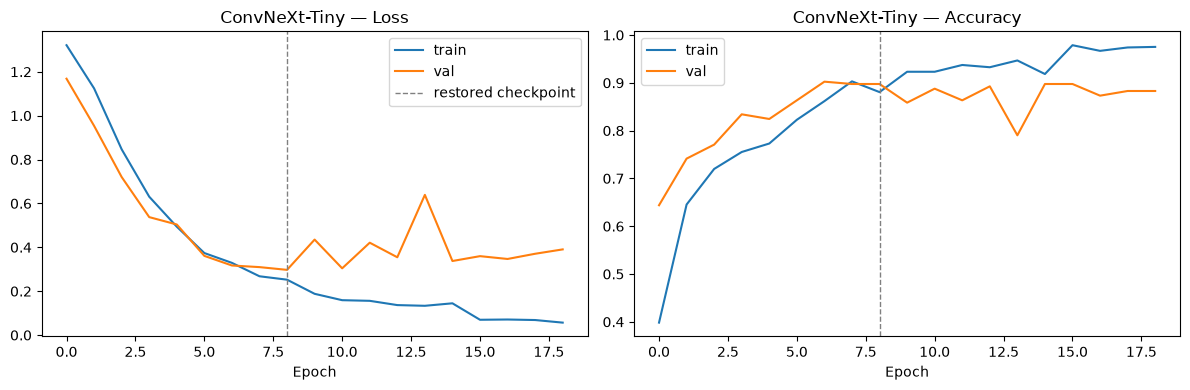

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.699


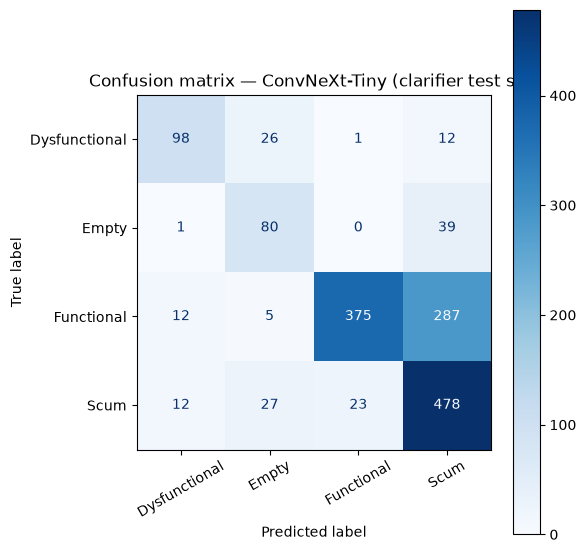

               precision    recall  f1-score   support

Dysfunctional      0.797     0.715     0.754       137
        Empty      0.580     0.667     0.620       120
   Functional      0.940     0.552     0.696       679
         Scum      0.586     0.885     0.705       540

     accuracy                          0.699      1476
    macro avg      0.726     0.705     0.694      1476
 weighted avg      0.768     0.699     0.698      1476



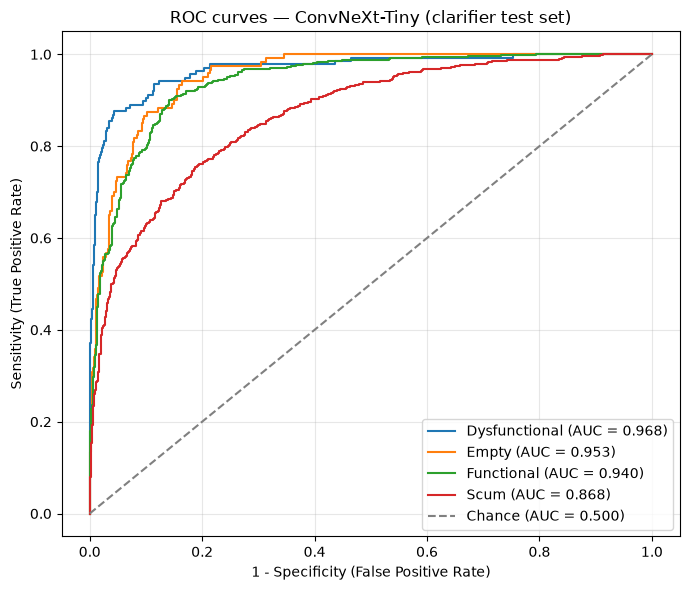

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.968
  Empty          : 0.953
  Functional     : 0.940
  Scum           : 0.868

Mean AUC (over 4/4 classes with test examples): 0.932


(np.float64(0.698509485094851),
 {'Dysfunctional': 0.9678919337341844,
  'Empty': 0.952839233038348,
  'Functional': 0.9404671051051162,
  'Scum': 0.8683424343146565})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/clarifier_aug/results_clarifier_convnext_tiny_CapeFlats.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
